# <span style="color: rgb(230, 0, 126);"> Tasca S8.01. Visualitzacions en Python</span>

Nom alumne: 		Roser Blasco							

Data: 01 Abril 2025

Corregit per: XX

Aquesta pràctica permetrà explorar com es poden utilitzar eines de visualització avançades en Python per a interpretar i presentar dades de manera efectiva, proporcionant una oportunitat valuosa per a millorar les habilitats analítiques i tècniques.

## <span style="color: rgb(245, 235, 245);"> Nivell 1</span>
### <span> Realitza la connexió en Python amb el MySQL Workbench per a carregar tota la informació que tens en les taules.</span>

#### <span style="color: rgb(245, 235, 245);"> Connectem Python amb MySQL</span>

In [2]:
#Instal·lem PipMysql si no el tenim instal·lat
%pip install pymysql

# Importem la llibreria pymysql
import pymysql

# Importem llibreria pandas 
import pandas as pd


# Ens conectem a la base de dades
connection = pymysql.connect(host='localhost',
                             user='root',
                             password= 'M@3QLr007',
                             db='modelat_sql_roser4')

if connection.open:
        print("S'ha connectact amb èxit a la base de dades modelat_sql_roser4")




[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
S'ha connectact amb èxit a la base de dades modelat_sql_roser4


#### <span style="color: rgb(245, 235, 245);"> Carreguem en un diccionari  "db_modelat_sql_a_python_roser" la info que tenim a les taules</span>

In [3]:
# Creem un cursor per a executar consultes
cursor = connection.cursor()

# Obtemin el llistat de les taules en la base de dades
cursor.execute("SHOW TABLES")
tables = cursor.fetchall()

# Creem un diccionari per a enmagatzemar els dataframes
db_modelat_sql_a_python_roser = {}
print("S'ha creat la base de dades buida db_modelat_sql_a_python_roser")

# Llegim cada taula com un DataFrame i l'enmagatzemem en el diccionari
for table in tables:
    table_name = table[0]  # El nombre de la taula
    query = f"SELECT * FROM {table_name}" # Llegir la taula com a DataFrame
    df = pd.read_sql(query, connection) 
    db_modelat_sql_a_python_roser[table_name] = df  # Enmagatzemar el DataFrame en el diccionari


# Imprimim la llista de dataframes enmagatzemats en el diccionari
print("S'han afegit les següents taules a la base de dades db_modelat_sql_a_python_roser")
for table_name, df in db_modelat_sql_a_python_roser.items():
    print(f"- {table_name}")


# print(db_modelat_sql_a_python_roser)

S'ha creat la base de dades buida db_modelat_sql_a_python_roser
S'han afegit les següents taules a la base de dades db_modelat_sql_a_python_roser
- companies
- credit_cards
- estat_targetes
- pont_trans_prod
- products
- transactions
- users
- vistamarketing


/var/folders/tj/x1zxmcgd19nbm3pz04lp5pv40000gn/T/ipykernel_1869/13430421.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


#### <span style="color: rgb(245, 235, 245);"> Unim totes les taules en una taula gran "db_taulagran", mitjançant la funció de merge</span>

Així no haurem de fer merge després entre dues o tres taules, encara que sabem que pot trigar més a fer les operacions quan facis servir taules més grans.

In [4]:
# Unim totes les taules en una base de dades gran, mitjançant la funció de merge
 
db_taulagran = db_modelat_sql_a_python_roser['transactions'].merge(db_modelat_sql_a_python_roser['companies'], left_on='business_id', right_on='id', how="outer", suffixes=('_transaccio', '_empresa'))

# Merge amb credit cards i canviar id de targeta per id_credit_cards
db_taulagran = db_taulagran.merge(db_modelat_sql_a_python_roser['credit_cards'], left_on='card_id', right_on='id', how="outer", suffixes=('_transaccio', '_targeta'))
db_taulagran = db_taulagran.rename(columns={'id': 'id_credit_cards'})

# Merge amb la taula pont
db_taulagran = db_taulagran.merge(db_modelat_sql_a_python_roser['pont_trans_prod'], left_on='id_transaccio', right_on='transaccio', how="outer",suffixes=('_transaccio', '_pont_trans_prod'))

# Merge amb productes i canviar id per id_producte
db_taulagran = db_taulagran.merge(db_modelat_sql_a_python_roser['products'], left_on='producte', right_on='id', how="outer")
db_taulagran = db_taulagran.rename(columns={'id': 'id_producte'})

# Merge amb la taula users i canviar id per id_user
db_taulagran = db_taulagran.merge(db_modelat_sql_a_python_roser['users'], left_on='user_id_transaccio', right_on='id', how="outer", suffixes=('_companies', '_users'))
db_taulagran = db_taulagran.rename(columns={'id': 'id_user'})

# Comprovem les columnes que tenim després de cada merge
for columna in db_taulagran.columns:
    print(columna)

id_transaccio
card_id
business_id
timestamp
amount
declined
product_ids
user_id_transaccio
lat
longitude
id_empresa
company_name
phone_companies
email_companies
country_companies
website
id_credit_cards
user_id_targeta
iban
pan
pin
cvv
track1
track2
expiring_date
transaccio
producte
id_producte
product_name
price
colour
weight
warehouse_id
id_user
name
surname
phone_users
email_users
birth_date
country_users
city
postal_code
address


#### <span style="color: rgb(245, 235, 245);"> Instal·lem  llibreries de gràfics: Seaborn i Matplotlib</span>

In [5]:
# Instal·lem la llibreria seaborn
%pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### <span style="color: rgb(245, 235, 245);">Transformacions al preu</span>

Per a poder canviar-lo, hem d'eliminar el símbol de dòlar, transformar els elements NaN de la columna a zero i canviar el tipus de dada a float
 

In [6]:
# Treiem el símbol $ 
db_taulagran['price'] = db_taulagran['price'].str.replace('$', '')

# Convertim el NaN a 0
db_taulagran['price'] = db_taulagran['price'].fillna(0)


# Canviem el tipus de la columna price a float https://www.geeksforgeeks.org/convert-pandas-dataframe-column-to-float/
db_taulagran['price'] = db_taulagran['price'].astype(float)


 

#### <span style="color: rgb(245, 235, 245);">Afegim una nova variable categòrica</span>

In [7]:
db_taulagran['franchise'] = db_taulagran['product_name']
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Direwolf Littlefinger', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('riverlands north', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Winterfell', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('duel tourney', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Lannister', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Dorne bastard', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('jinn Winterfell', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Tully maester Tarly', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('north of Casterly', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('skywalker ewok sith', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Winterfell Lannister', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Karstark Dorne', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Lannister Barratheon Direwolf', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('palpatine chewbacca', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('duel', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Tarly Stark', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('skywalker ewok', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Tully', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('dooku solo', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Tully Dorne', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Direwolf riverlands the', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Direwolf Stannis', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('kingsblood Littlefinger the', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('duel tourney Lannister', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('south duel', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('duel Direwolf', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Direwolf', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Stannis warden', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('the duel warden', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Karstark warden', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('warden Karstark', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('chewbacca mustafar', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('south duel tourney', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Stark Karstark', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Stannis riverlands', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('north', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('duel warden', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('of north', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('the giantsblood maester', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('ewok sith', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('warden', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('warden south duel', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('tatooine dooku solo', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('sith', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('south', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('giantsblood maester Karstark', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('rock Renly in', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('in', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('north Tully', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('riverlands the duel', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Tully maester', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Direwolf riverlands', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Direwolf Stannis riverlands', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('solo palpatine chewbacca', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('rock Renlythe duel', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Jade tatooine dooku', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('riverlands the', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('mustafar jinn', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Littlefinger the giantsblood', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Littlefinger Tarly', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Tarly Littlefinger', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Karstark Tully Dorne', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('bastard of north', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Stark kingsblood', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('sith Jade', 'Star Wars')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Stannis warden south', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('Littlefinger Tarly Stark', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('in south Winterfell', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('riverlands north Direwolf', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('rock Renly', 'Game of Thrones')
db_taulagran['franchise'] = db_taulagran['franchise'].replace('the duel', 'Game of Thrones')

db_taulagran['franchise'].unique()

array([nan, 'Game of Thrones', 'Star Wars'], dtype=object)

------------------------------------------------------------------------------------

### <span style="color: rgb(230, 0, 126);">Exercici 1: Una variable numèrica</span>




#### <span style="color: rgb(245, 235, 245);">Histograma</span>

Un histograma ens representa la distribució dels pesos dels productes.

Veiem que, de forma general, els productes tendeixen bé a pesar molt poc o molt. És a dir, bé un kg o bé a pesar al voltant de 3kg. 

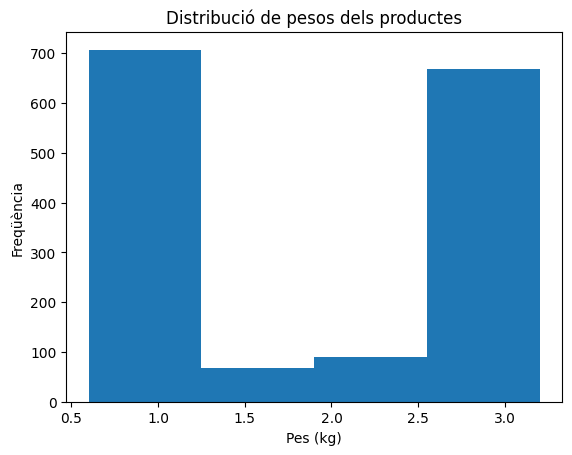

In [8]:
db_taulagran["weight"].plot.hist(bins = 4)
plt.xlabel("Pes (kg)")
plt.ylabel("Freqüència")
plt.title("Distribució de pesos dels productes")
plt.show()

### <span style="color: rgb(230, 0, 126);"> Exercici 2: Dues variables numèriques </span>




#### <span style="color: rgb(245, 235, 245);">Scatterplot amb regressió</span>

Amb aquest tipus de gràfic, intentem veure si hi ha una relació entre el pes i el preu dels productes, que seria difícil de detectar únicament amb un scatterplot. 

El que veiem és que la línia indica que a un major pes sí que els productes tendirien a valer una mica més. Aquesta correlació és important no donar per suposada la causació, que no podem demostrar encara. 

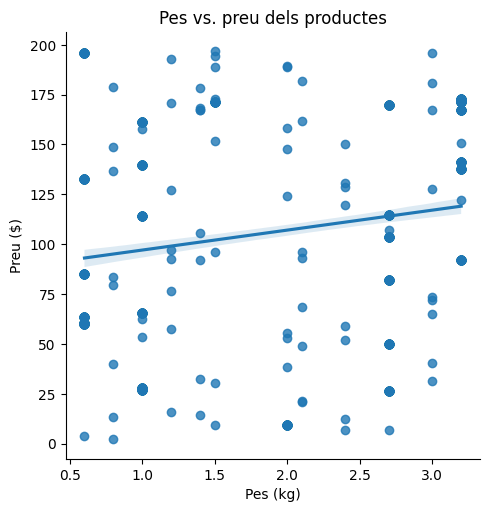

In [9]:
import seaborn as sns

sns.lmplot(data=db_taulagran, x='weight', y='price')
plt.title("Pes vs. preu dels productes")
plt.xlabel("Pes (kg)")
plt.ylabel("Preu ($)")
plt.show()

### <span style="color: rgb(230, 0, 126);">Exercici 3: Una variable categòrica</span>



#### <span style="color: rgb(245, 235, 245);">Diagrama de sectors</span>

Per a representar una variable categòrica, utilitzarem el recompte de les vegades que apareix. 

Aquí emprem el diagrama de pastís amb la intenció és comparar la mida d'una secció amb tot el pastís, en lloc de comparar els talls entre ells.

El que veiem mitjançant aquest diagrama, és que les empreses ofereixen proporcionalment molts més productes de la serie "Joc de trons" que de la saga "La guerra de les galàxies" i hauriem de veure per què, si és un tema de llicències o de drets, per exemple.

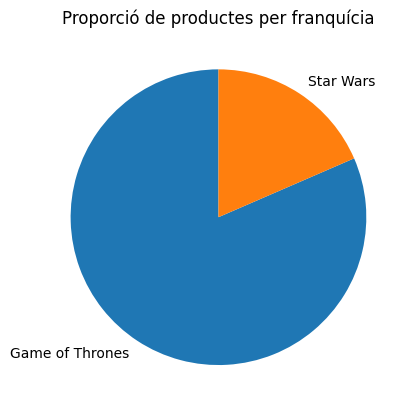

In [10]:
franquicies = db_taulagran['franchise'].value_counts()
franquicies.plot.pie(startangle=90, title = "Proporció de productes per franquícia")
plt.ylabel("")
plt.show()

### <span style="color: rgb(230, 0, 126);">Exercici 4: Una variable categòrica i una numèrica</span>




#### <span style="color: rgb(245, 235, 245);">Diagrama de barres</span>

Volem comparar el que han ingressat les empreses de cada país, és a dir, el que han venut en total, sense tenir en compte si les transaccions han segut rebutjades o no.

Sumem els amunts de cada transacció i les representem per països. Aquí veiem clarament uque ho ha dos grups de països: els que reben més volum en transaccions (Alemanya, Regne Unit, Suècia, Noruega, Irlanda i Canadà) i el grup dels que no en venen tant (Austràlia, Bèlgica, Xina, França, Itàlia, Holanda, Nova Zelanda, Espanya i Estats Units).

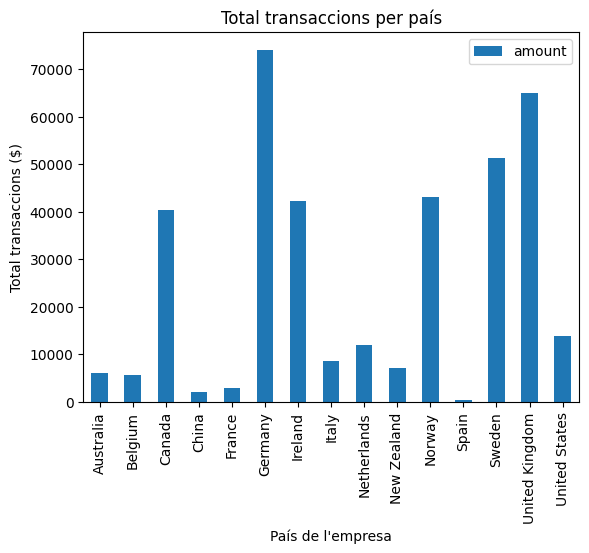

In [11]:
total_despesa_per_pais_dempresa = db_taulagran.groupby("country_companies")[["amount"]].sum().plot.bar()
plt.title("Total transaccions per país")
plt.xlabel("País de l'empresa")
plt.ylabel("Total transaccions ($)")
plt.show()


### <span style="color: rgb(230, 0, 126);">Exercici 5: Dues variables categòriques</span>




#### <span style="color: rgb(245, 235, 245);">Diagrama de barres apilades</span>

Amb un diagrama de barres apilades volem veure d'on venen les transaccions declinades i quin impacte tenen en el número de transaccions segons el país d'origen del usuaris.
Veiem que el problema està exclusivament centrar en Canadà, caldira veure si hi ha algun problema específic amb les targetes de crèdit canadiense que estigui donant problemes a la web a la hora de cobrar  

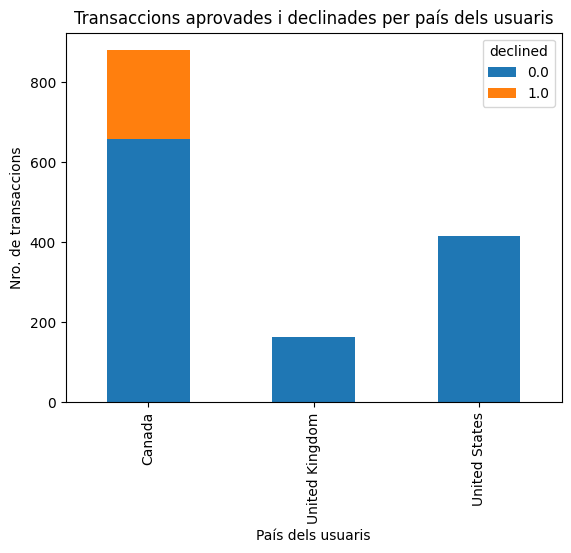

In [12]:

taula_agrupadas = pd.crosstab(db_taulagran["declined"], db_taulagran["country_users"]).transpose()
taula_agrupadas.plot.bar(title= "Transaccions aprovades i declinades per país dels usuaris", stacked=True)

plt.ylabel("Nro. de transaccions")
plt.xlabel("País dels usuaris")
plt.show();

### <span style="color: rgb(230, 0, 126);">Exercici 6: Tres variables</span>




#### <span style="color: rgb(245, 235, 245);">Boxplot amb hue</span>

Amb aquest diagrama de caixa que representa els quartils, veiem no només com es distribueix l'import per país, sinò també si la franquícia del producte té un impacte sobre la despesa transaccionada. 

I clarament podem veure que els usuaris d'Estats Units que compren productes de la saga "La Guerra de les Galàxies" gasten major quantitat de dòlars en les transaccions. Tant en la mitjana com en les posicions del quartil Q1 i Q3. Hauriem de provar doncs, suggerir a usuaris d'aquest país els productes d'aquesta saga abans del checkout. 

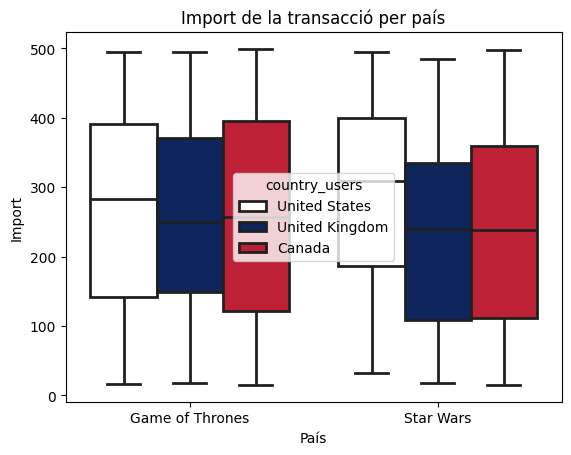

In [13]:
import seaborn as sns

#Paleta
paisos_palette = ["#FFFFFF", "#012169", "#d80621"]


sns.boxplot(x=db_taulagran['franchise'], 
            y=db_taulagran['amount'],
            linewidth=2,
            hue=db_taulagran['country_users'],
            palette=paisos_palette)

# Mou la llegenda https://seaborn.pydata.org/generated/seaborn.move_legend.html
# No ho he aconseguit

# Títol i etiquetes
plt.title("Import de la transacció per país")
plt.ylabel("Import")
plt.xlabel("País")
plt.show()

### <span style="color: rgb(230, 0, 126);">Exercici 7: Graficar un Pairplot</span>




#### <span style="color: rgb(245, 235, 245);">Pairplot</span>

Un Pairplot mostra la relació entre dues variables, però només les que tenen valor numèric.

Li hem afegit un hue per a fer-lo una mica interessant. Aquí doncs veiem que hi ha tot tipus de productes en les transaccions declinades. Tammateix, el que està clar és que les transaccions declinades és un problema d'uns usuaris molt espefícics. 

Pairplot de la bbdd, per declinades


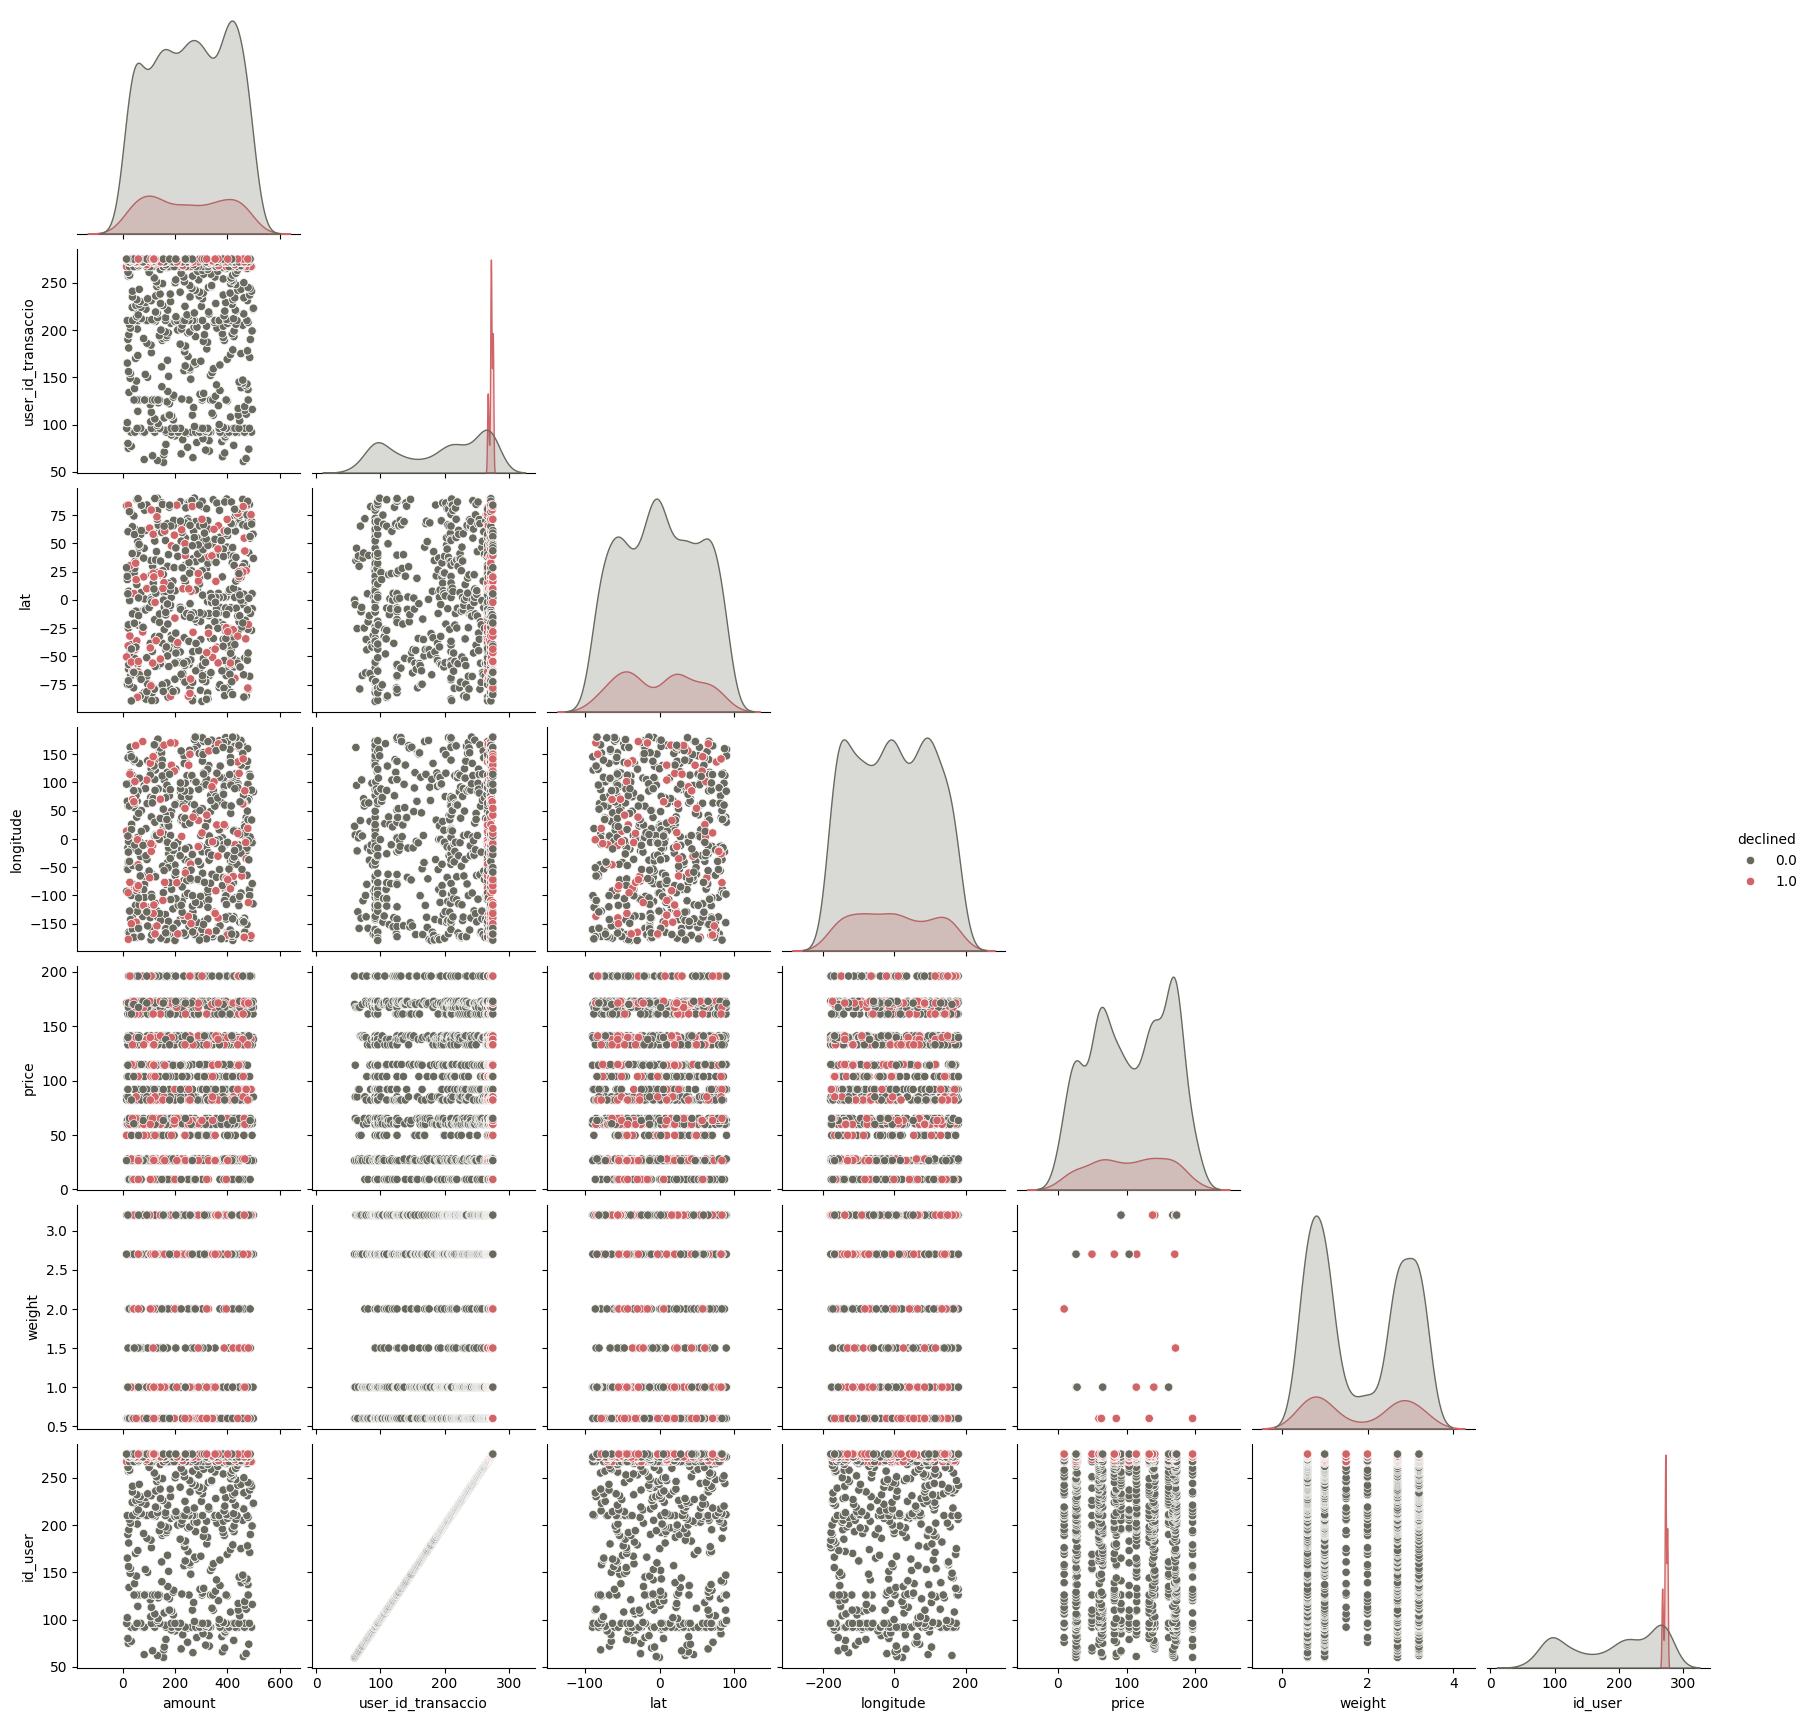

In [14]:
print ('Pairplot de la bbdd, per declinades')

import seaborn as sns
# use a handmade palette
declinades_palette = ["#69695F", "#D16466"]

sns.pairplot(db_taulagran, 
            hue='declined', 
            corner=True,
            palette=declinades_palette)

plt.show()

## <span style="color: rgb(245, 235, 245);"> Nivell 2</span>

### <span style="color: rgb(230, 0, 126);">Exercici 1: Correlació de totes les variables numèriques</span>




#### <span style="color: rgb(245, 235, 245);">Correlació</span>

Aquí seleccionem totes les variables numèriques, i utilitzem un corr() per a que ens mostri una taula amb totes les correlacions.
La visualització que elegim és un heatmap, on cada valor de la matriu és representada amb un color.
Clarament hi haurà una correlació perfecta (1) de les variables amb elles mateixes, en la diagonal de la taula i també entre user_id_transaccio i id_user.

Veurem que en aquest cas, la relació entre varaibles és molt poc significativa excepte la que marca el id d'usuari i que les transaccions siguin declinades. Com hem vist abans, el fet que es declinin transaccions és problema d'uns usuaris específics. 



Correlació de totes les variables numèriques


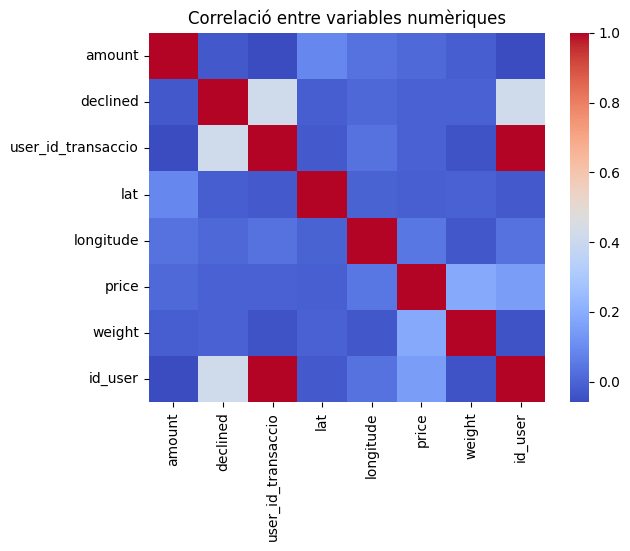

In [24]:
print("Correlació de totes les variables numèriques")
correlacio_numeriques = db_taulagran.select_dtypes(include = "number") # Molt útil per a fer correlacions, groupbys, gràfics, etc.
sns.heatmap(correlacio_numeriques.corr(), cmap="coolwarm")
plt.title("Correlació entre variables numèriques")
plt.show()

### <span style="color: rgb(230, 0, 126);">Exercici 2: Implementa un jointplot</span>




#### <span style="color: rgb(245, 235, 245);">Jointplot</span>

La funció jointplot dibuixa dues variables amb gràfics univariants i multivariants. 
Per a fer-lo més interessant, li afegirem hue.

Aquí hem optat per mirar la relació de declinades, el id d'usuari i la franquícia.
Veiem que cap usuari té més preferència per Star Wars que per Joc de trons, i que tant en transaccions appectades i declinades hi ha més productes de Joc de trons. 
Consistent amb això, els usuaris amb tranasaccions declinades tenen interés en les dues coses però majoritàriament en Joc de trons. 



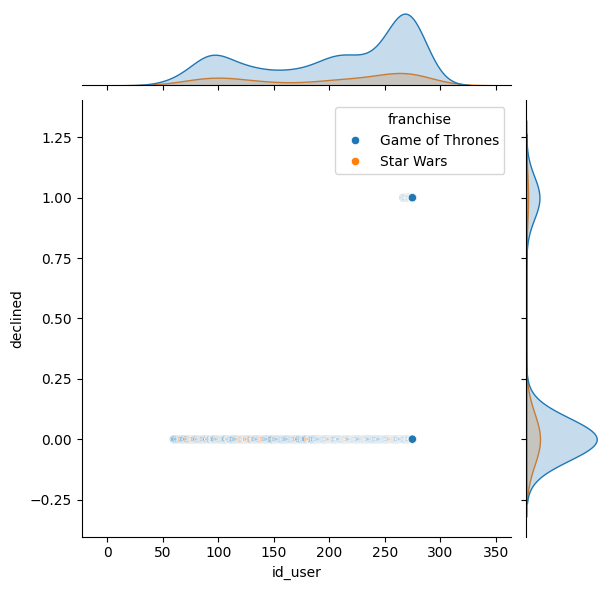

In [ ]:
sns.jointplot(data=db_taulagran, y="declined", x="id_user", hue="franchise")
plt.show()

## <span style="color: rgb(245, 235, 245);"> Nivell 3</span>

### <span style="color: rgb(230, 0, 126);">Exercici 1: Implementa un violinplot combinat amb un altre tipus de gràfic</span>




#### <span style="color: rgb(245, 235, 245);">Violinplot amb beeswarm</span>

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.7% of the points cannot be placed; you may want to decrease the size of the markers or use st

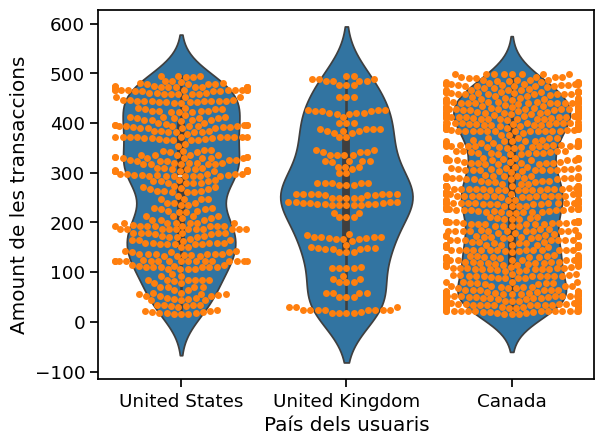

In [ ]:
# Violin plot with Beeswarm https://python-graph-gallery.com/502-violinplot-and-swarmplot/

# Plot the violin
ax = sns.violinplot(y="amount", 
                    x="country_users", 
                    data=db_taulagran)

ax = sns.swarmplot(y="amount",
                   x="country_users",
                   data=db_taulagran) 

ax.set_title("Import de les transaccions per país dels usuaris")
ax.set_xlabel("País dels usuaris")
ax.set_ylabel("Amount de les transaccions")
plt.show();

### <span style="color: rgb(230, 0, 126);">Exercici 2: Genera un FacetGrid per a visualitzar múltiples aspectes de les dades simultàniament</span>




#### <span style="color: rgb(245, 235, 245);">Facetgrid</span>

Un FacetGrid ajuda a visualitzar la distribuió d'una variable així com la relació entre múltiples variables en varis grups de la base de dades. Es pot dibuixar amb tres dimensions: fila, columna i hue. Les dues primeres es corresponen amb la organització de les gràfiques i la tercera diferencia per color. Les variables han de ser categòriques.

Aquí grafiquem el preu dels productes comprats en gràfiques separades per a combinacions de franquícia i país de l'empresa. Entre les coses que podem veure, per exemple, és que a Suècia hi ha una preferència per els productes més barats de Game of Thrones i d'entre els de Star Wars, els més cars.  

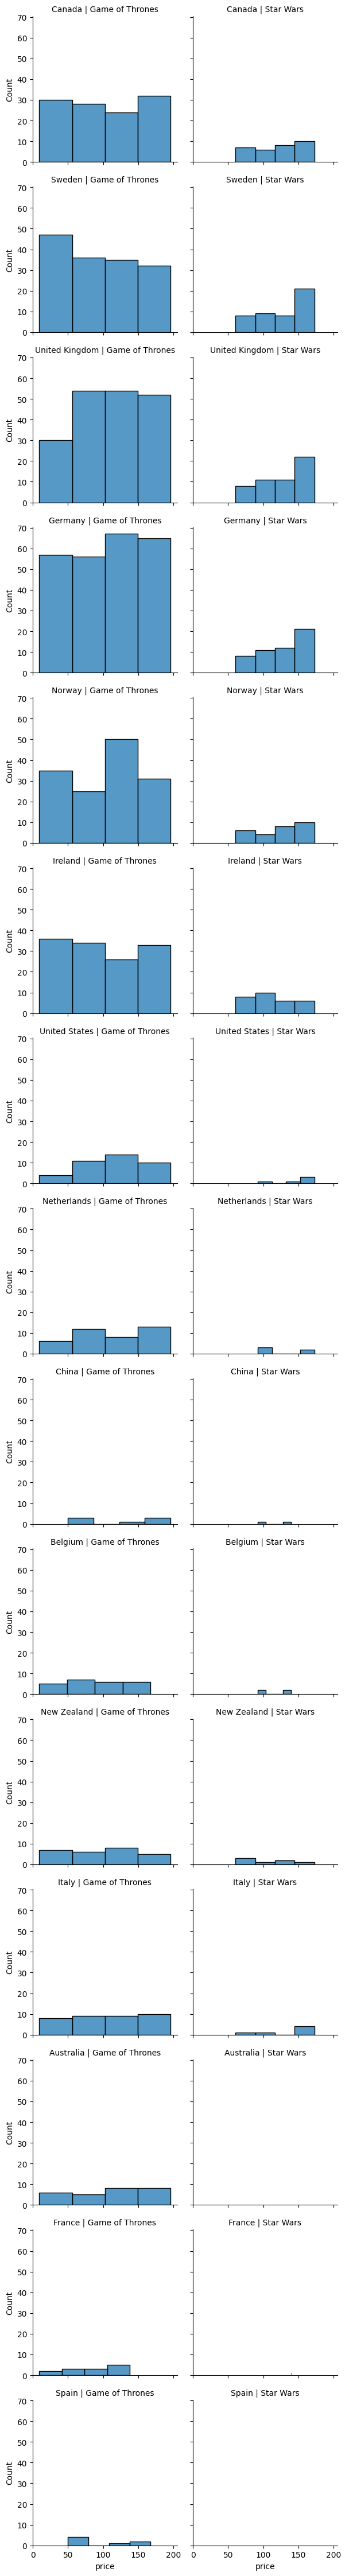

In [18]:
g = sns.FacetGrid(db_taulagran, col="franchise", row="country_companies")
g.map(sns.histplot, "price", bins=4)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend()  # Llegenda
plt.show()

Ara baixem el csv per a importar-lo a Power BI ja que en MAC hem tingut problemes per a conectar-lo.

In [177]:
db_taulagran.to_csv('taulagran.csv')
